# Exploring Reddit posts
Emilio Lehoucq - 2/20/24

## Importing libraries

In [1]:
import pandas as pd
import nltk
print(f'nltk version: {nltk.__version__}')
import matplotlib.pyplot as plt

nltk version: 3.8.1


## Reading data

In [2]:
df = pd.read_csv('reddit_mindfulness_parsed.csv', index_col = 0)

## Exploring data

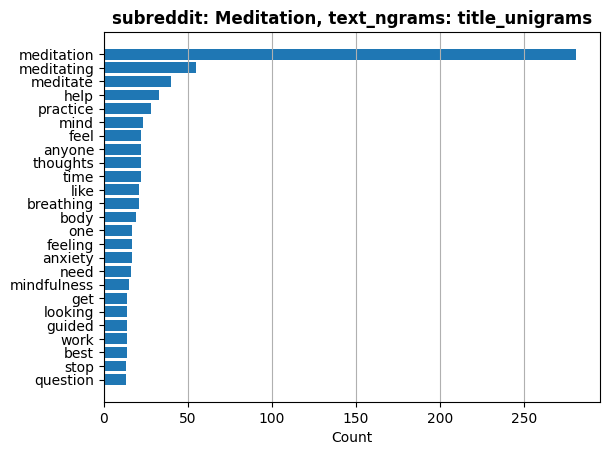

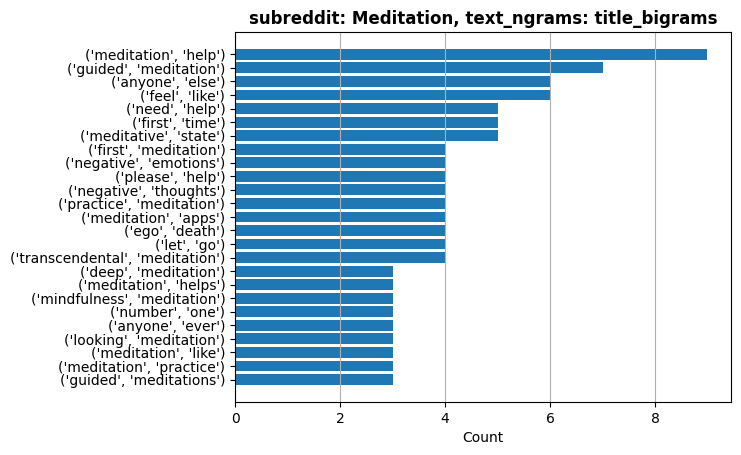

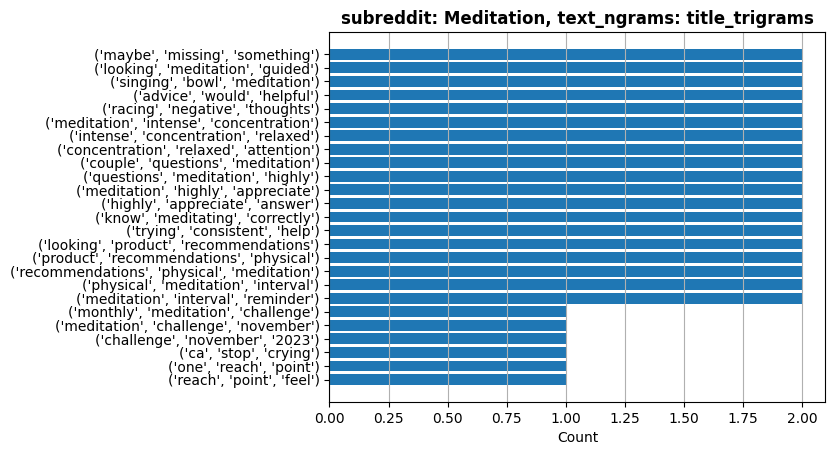

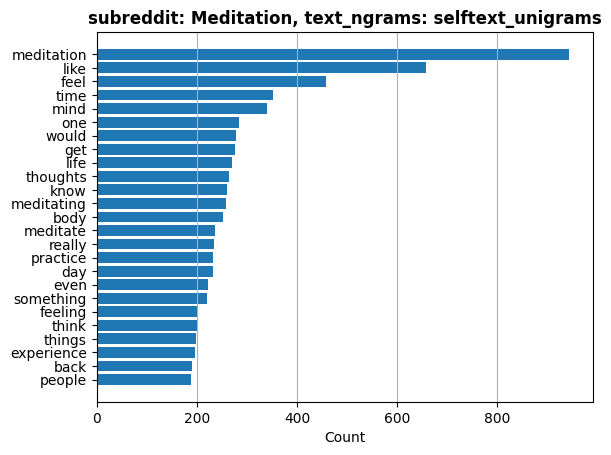

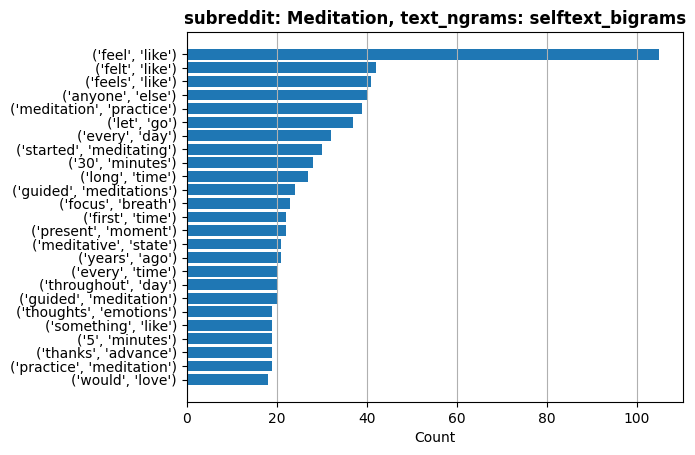

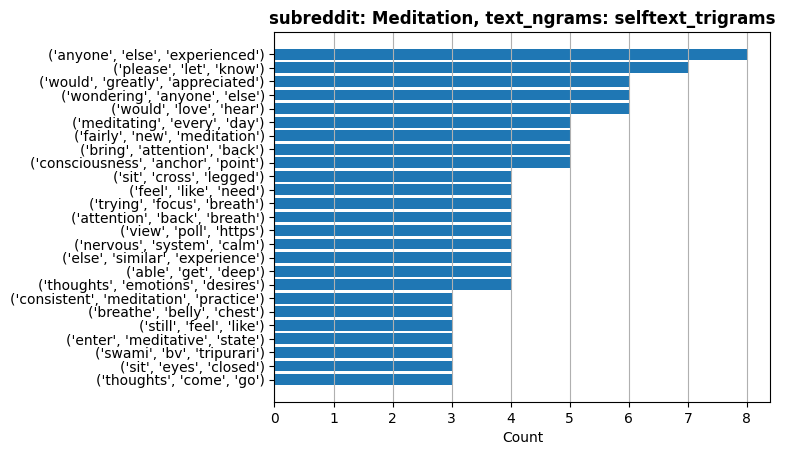

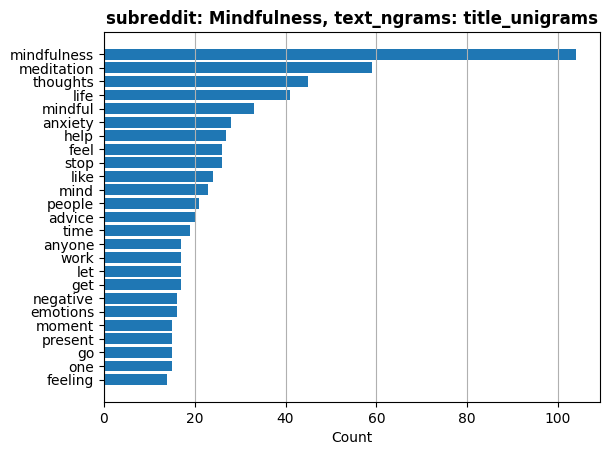

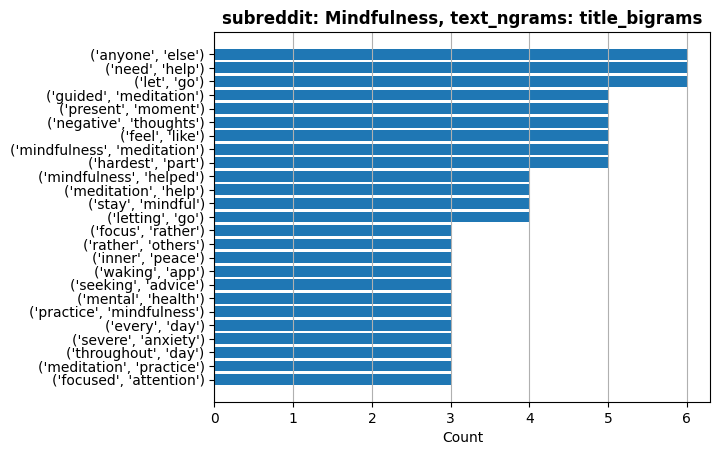

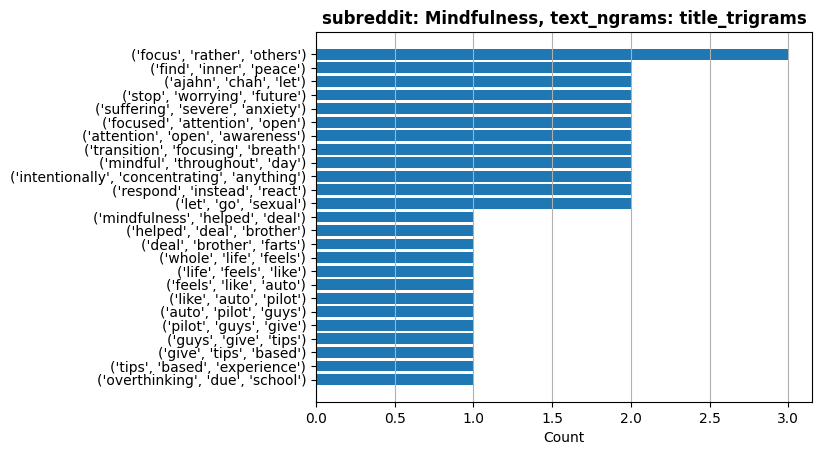

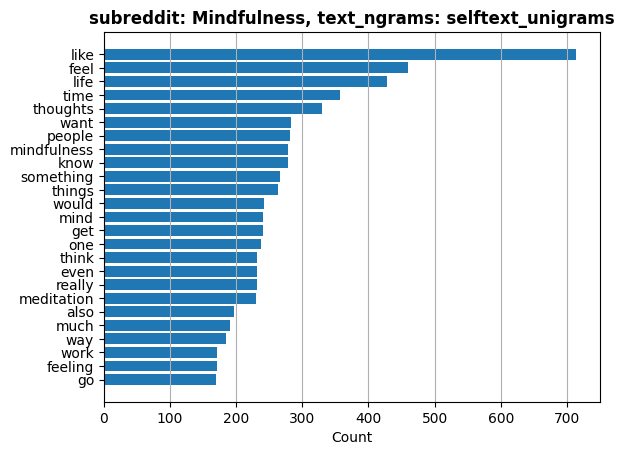

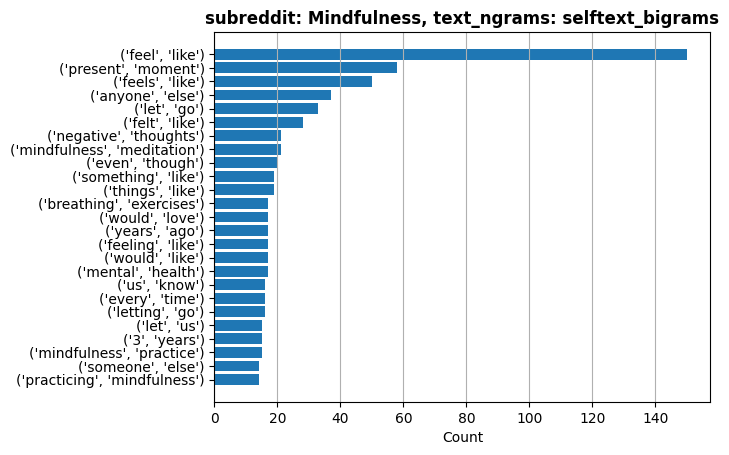

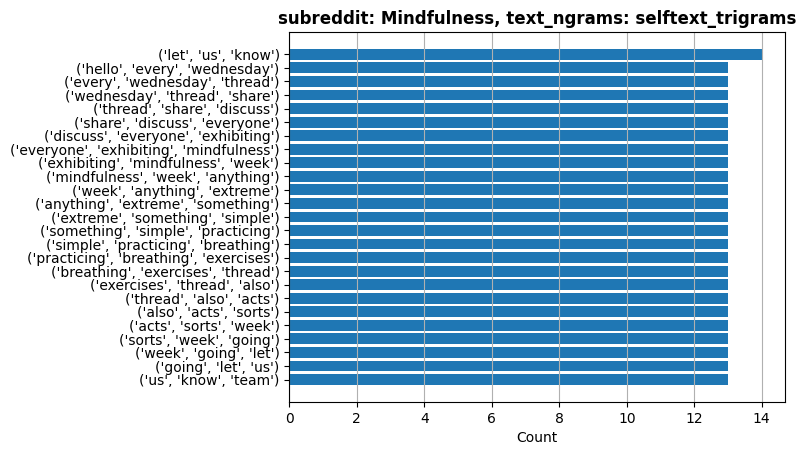

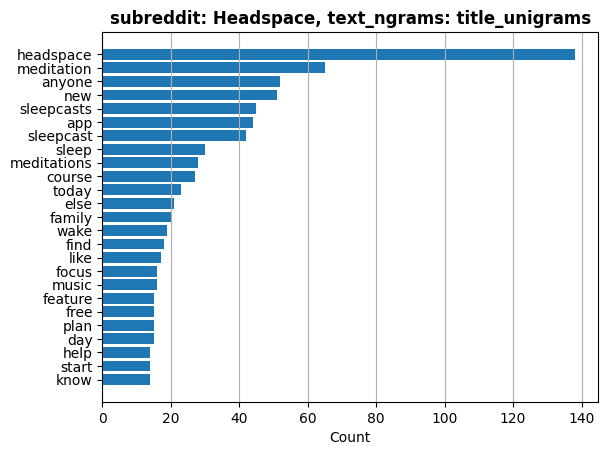

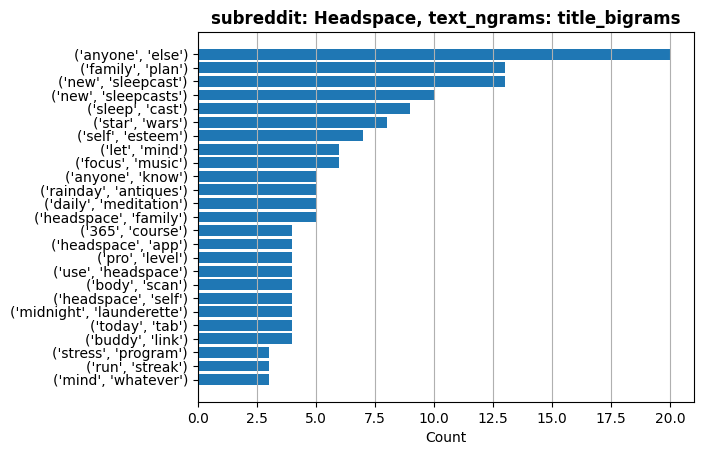

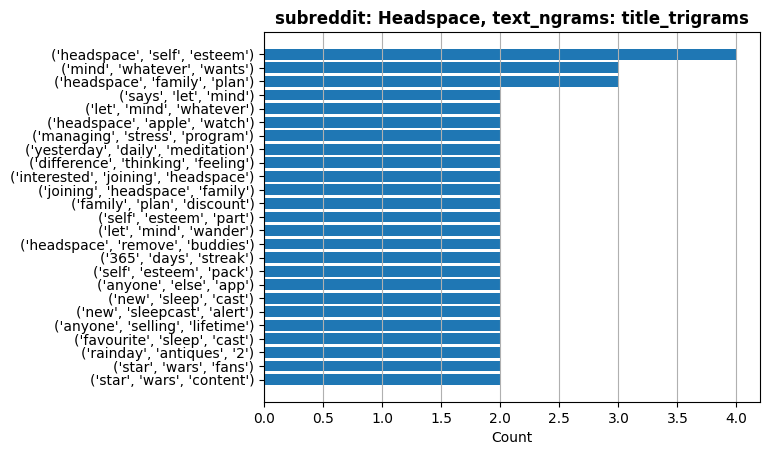

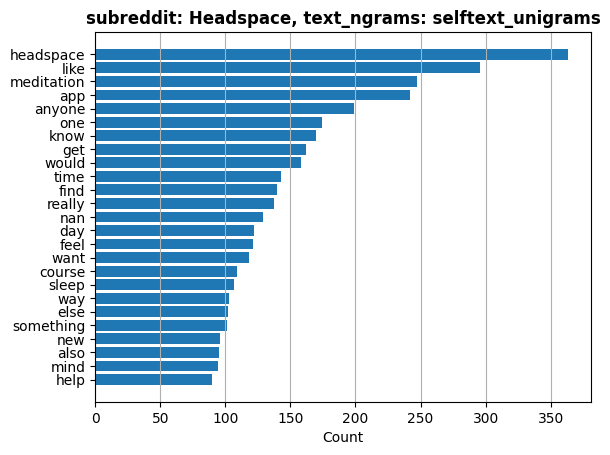

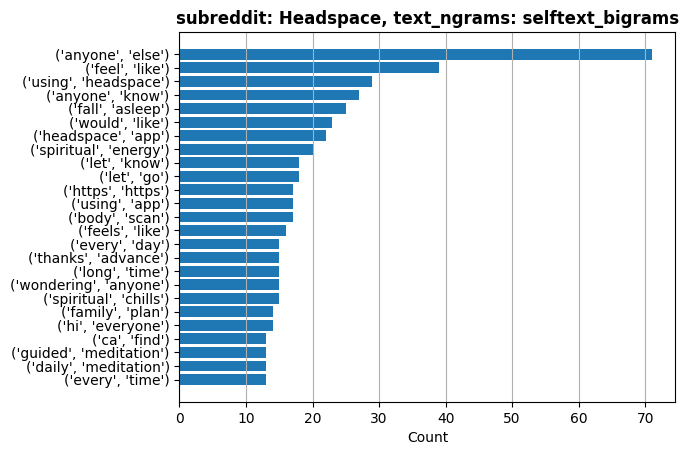

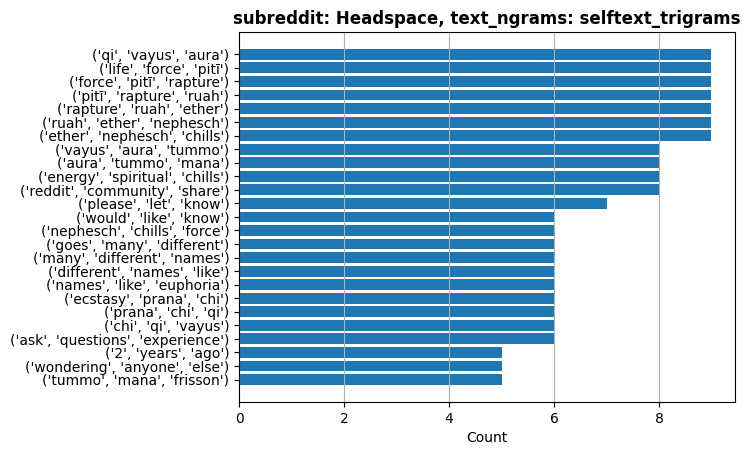

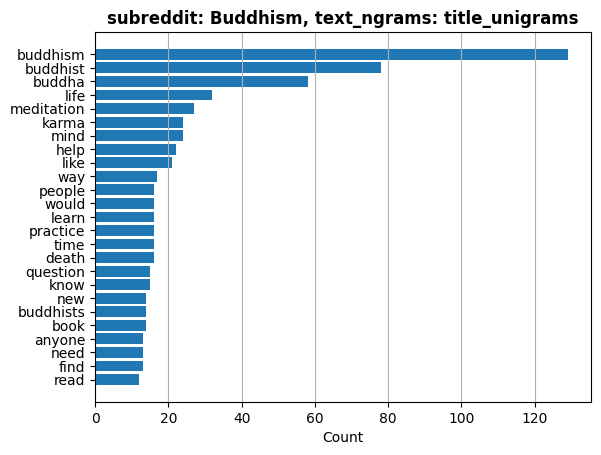

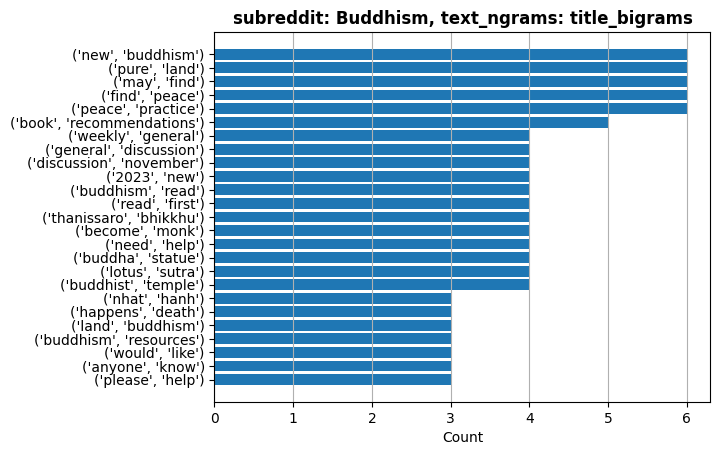

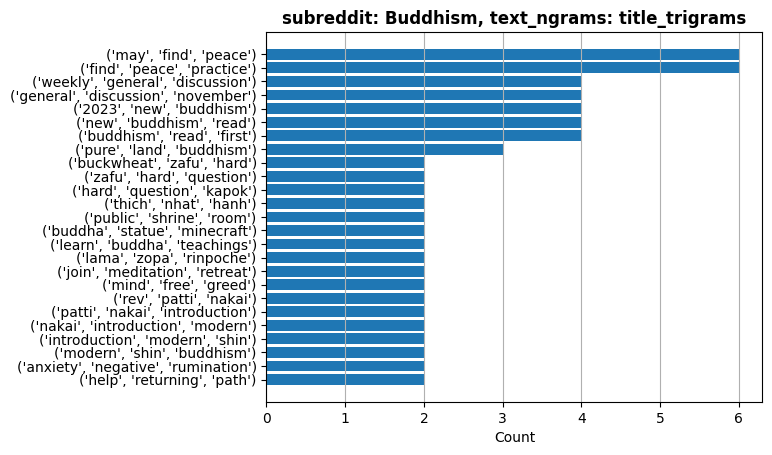

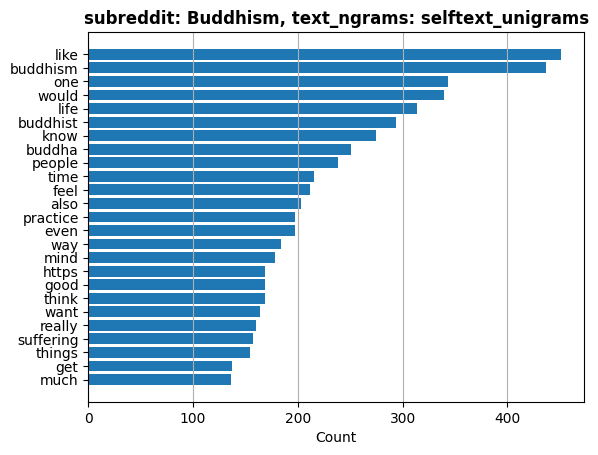

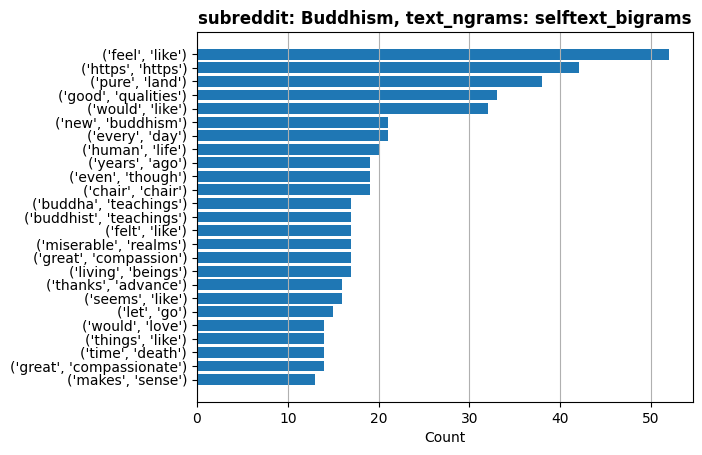

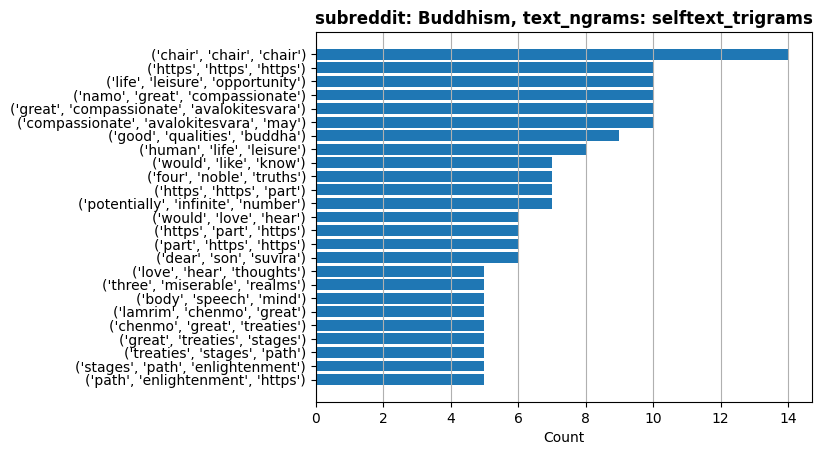

In [3]:
# Creating dataframe to store lists of ngrams for each subreddit and the frequency distributions
frequency_distributions = pd.DataFrame(
    {
        'subreddit': [i for i in df['subreddit'].unique().tolist() for _ in range(6)],
        'text_ngrams': [col for col in df.columns if col.endswith('grams')] * 4,
        'ngrams': None,
        'freqdis': None
    }
)

# Iterating over rows of frequency_distributions
for i, row in frequency_distributions.iterrows():
  # List to temporarily store ngrams for a given text_ngrams of a given subreddit
  ngrams = []
  # Saving current subreddit and text_ngrams to avoid repetition
  subreddit = row['subreddit']
  text_ngrams = row['text_ngrams']
  # Iterating over ngrams for a given text_ngrams of a given subreddit
  for ngram in df[df['subreddit'] == subreddit][text_ngrams]:
    # Adding each list of ngrams to the list
    ngrams += eval(ngram) # Using eval because otherwise it's a string--not a list
  # Storing ngrams for a given text_ngrams of a given subreddit
  frequency_distributions.at[i, 'ngrams'] = ngrams
  # Storing frequency distribution for given ngrams
  frequency_distributions.at[i, 'freqdis'] = nltk.FreqDist(ngrams)
  # Plotting most common ngrams
  # Could also use: https://deepnote.com/@code-along-tutorials/Natural-Language-Processing-in-Python-Exploring-Word-Frequencies-with-NLTK-47ec085a-7a46-4f5d-89a1-e08be7d164c5
  most_common = row['freqdis'].most_common(25)
  ngrams_to_plot = [str(ngram[0]) for ngram in most_common]
  counts_to_plot = [ngram[1] for ngram in most_common]
  plt.barh(ngrams_to_plot, counts_to_plot)
  plt.gca().invert_yaxis() # https://stackoverflow.com/questions/34076177/matplotlib-horizontal-bar-chart-barh-is-upside-down
  plt.grid(axis = 'x')
  plt.title(f'subreddit: {subreddit}, text_ngrams: {text_ngrams}', weight = 'bold')
  plt.xlabel('Count')
  plt.show()

There are a lot of http and https. Should probably go back and remove hyperlinks when parsing.

Across all subreddits there seem to be a lot of “first timers” asking for help/advice and seeking validation of their experience (thoughts, feelings). Time also seems to be an important topic of discussion. Sometimes it’s seems to be the time that people meditate, other times the time for which someone has meditated, and yet other times it seems to be time itself as a topic.

In the Meditation, Mindfulness, and Headspace, guided meditations seem to be prominent.

In the Meditation and Mindfulness subreddits there seem to be some important conversations about being in the present moment, stopping, and letting go. Negative emotions and thoughts, particularly anxiety, also seem to be a recurring theme. There seem to be a lot of talk about breathing.

In the Meditation and Buddhism subreddits (and the Mindfulness one to some degree), it seems to be more common talk about “practice”—probably meditation practice. Also, it seems to be more common to talk about meditation postures, particularly sitting cross-legged (in Meditation), Zafu cushions (Buddhism), and chairs (Buddhism).

In the Meditation subreddit there seems to be some talk about the body. The back also seems to be mentioned a fair amount, probably back pain.

In the Headspace subreddit, besides the app itself (courses, features) sleepcasts/sleep seem to be a key theme. There also seems to be some talk about music.

In the Buddhism subreddit, meditation is an important topic, but along with conversation about the teachings of the Buddha and Buddhism (and teachers like Thich Nhat Hanh) and topics such as karma, suffering, death, and compassion. Also, people seem to be discussing books.

## Exporting data to CSV

In [4]:
frequency_distributions.to_csv('reddit_mindfulness_ngrams_freqdis.csv')